In [1]:
# Execute this cell
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
#%matplotlib inline
#%config InlineBackend.figure_format='retina'

from scipy import integrate
from scipy.stats import norm

#!pip install emcee

import emcee


In [2]:
import numpy as np
import pandas as pd
import emcee
import h5py

print(f"NumPy version: {np.__version__}") # Dovrebbe essere 1.26.x

NumPy version: 2.4.4


In [3]:
import pymc as pm
import numpy as np
import arviz as az

C:\Users\annat\AppData\Roaming\Python\Python311\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## Tasks



1) Read in `solutions/transient.npy`. This is a (100 x 3) numpy array, containing some time-series measurements from a transient phenomenon. The first column is time (arbitrary units), the second column is the flux (arbitrary units), and the third column are homoescedastic measurement uncertainties on the flux. Plot this data with the uncertainties.

2) One possible model for this data is a sharp burst with an exponential tail rising above a nominal background level. This model can be described as:

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

where $b$ is the background amplitude, $A$ is the burst amplitude, $t_0$ is the burst epoch, and $\alpha$ encodes how rapidly the burst dies off.

Code this burst model, and code a likelihood function for this data with the burst model. *Hint: This is similar in spirit to the likelihood when fitting polynomials to data, except now $x$ is time, and the polynomial model is now the burst model.* 

3) Using one of the MCMC sampler that we looked at in class (`emcee`, `pymc`), perform a Bayesian analysis that recovers an MCMC chain of posterior probability samples for the joint parameter space of $\{b,A,t_0,\alpha\}$. You must decide on how many samples are appropriate for running your MCMC. For your priors, make them $b\in \mathrm{Uniform}[0,50]$, $A\in \mathrm{Uniform}[0,50]$, $t_0\in \mathrm{Uniform}[0,100]$, and $\ln\alpha\in \mathrm{Uniform}[-5,5]$ (careful: uniform in $\ln\alpha$, not $\alpha$).

4) Perform an appropriate check to burn-in your chain, and thin the chain by selecting only points every auto-correlation length. If you are left with a small number of samples after thinning then you may need to run your MCMC for longer in (3).

5) Make a corner plot of the $4$-D parameter space, with labels, $[68,95]\%$ credible levels and quantiles, and titles.

6) Now choose $100$ samples randomly from your burned, thinned chain and plot the $100$ corresponding burst time-series on a figure along with the original data. You may want to choose a transparency for these $100$ burst curves that allows you to see everything nicely. These are showing the posterior spread of model solutions that are consistent with the data.

7) For each parameter, find the median and 90% credible region of the marginalized distribution and quote results as, for instance, $t_0=X^{+Y}_{-Z}$ 



### Data and model inspection

In [4]:
data = np.load("../solutions/transient.npy")

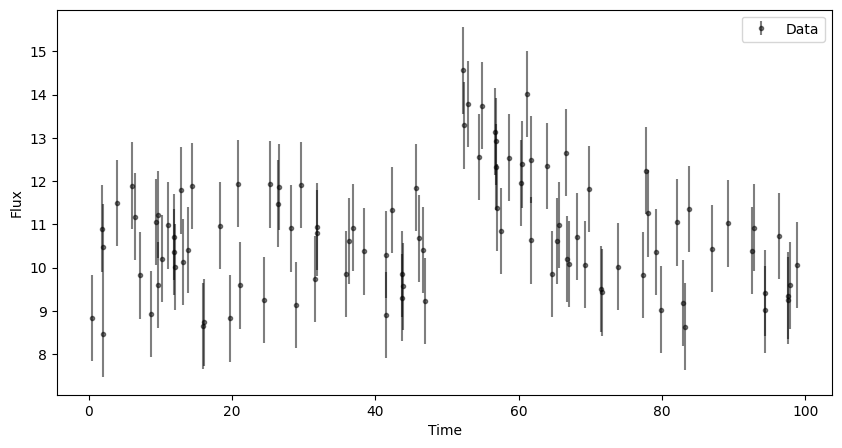

In [5]:
t, y, y_err = data[:, 0], data[:, 1], data[:, 2]


plt.figure(figsize=(10, 5))
plt.errorbar(t, y, yerr=y_err, fmt='.k', capsize=0, alpha=0.5, label='Data')
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()

In [6]:
def burst_model(theta, t):
    b, A, t0, alpha = theta
    model = np.full_like(t, b)  # Costant background b
    mask = t >= t0
    model[mask] += A * np.exp(-(t[mask] - t0) *alpha)
    return model

    return -0.5 * np.sum(((y - model) / y_err)**2)

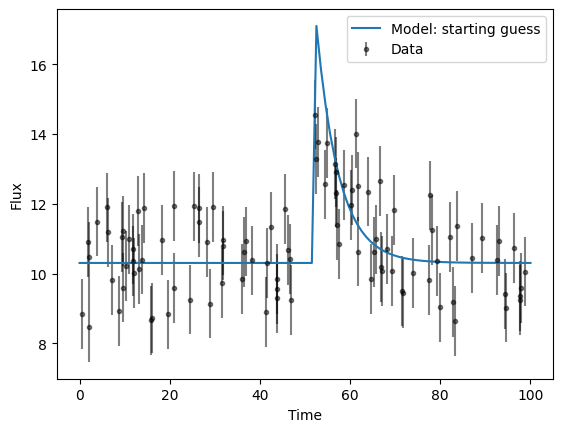

In [7]:
t_ax = np.linspace(0,100,100)
initial_guess = [np.mean(y[:10]), np.max(y)/2, t[np.argmax(y)], 0.2] #possible parameters
y_ax = burst_model(initial_guess, t_ax)
plt.errorbar(t, y, yerr=y_err, fmt='.k', capsize=0, alpha=0.5, label='Data')
plt.plot(t_ax,y_ax,label='Model: starting guess')
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()

### EMCEE 

Assuming the measurement uncertainties ($\sigma$) are Gaussian and independent, the likelihood is given by: 

$$\mathcal{L} \propto \exp\left( -\frac{1}{2} \sum \frac{(y_i - M(t_i; \theta))^2}{\sigma_i^2} \right)$$

where $M(t; \theta)$ is the model and it describes how well the last describes the data.

Priors instead encode the state of knowledge before seeing the data. Uniform priors for the physical parameters $b,A, t_0$ and the logarithm of $\alpha$ (therefore a log-uniform for $\alpha$) have been chosen.

The posterior $P(\theta|D)$: according to Bayes' Theorem: $$P(\theta|D) \propto \text{Likelihood} \times \text{Prior}$$

In [8]:
def log_likelihood(theta, t, y, y_err):
    model = burst_model(theta, t)
    # Assuming homoscedastic gaussian errors
    return -0.5 * np.sum(((y - model) / y_err)**2)

def log_prior(theta):
    b, A, t0, alpha = theta
    if 0<b<50 and 0<A<50 and 0<t0<100 and alpha>0:
        return -np.log(alpha)
    else:
        return -np.inf



def log_posterior(theta, t, y, y_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, y, y_err)

In [9]:
# Setup emcee
n_walkers = 20
n_params = 4
steps = int(1e4)
# Initial guess based on visual ispection
initial_guess = [np.mean(y[:10]), np.max(y)/2, t[np.argmax(y)], 0.2]
pos = initial_guess + 1e-3 * np.random.randn(n_walkers, n_params)

sampler = emcee.EnsembleSampler(n_walkers, n_params, log_posterior, args=(t, y, y_err))

# Run MCMC
print("Running production...")
sampler.run_mcmc(pos, steps, progress=True)

You must install the tqdm library to use progress indicators with emcee


Running production...


State([[10.25600117  6.81434879 48.21056658  0.12491283]
 [10.27614342  7.22805722 49.09461536  0.14694121]
 [10.31227348  4.95100689 51.00684263  0.12430241]
 [10.05552273  6.18267644 48.87343414  0.11387347]
 [10.31106136  5.8387456  47.74882049  0.11416088]
 [10.36246084  6.10600583 48.90339305  0.1401457 ]
 [10.31082005  5.17261812 49.46524293  0.13046314]
 [10.15383107  3.8785138  50.97071462  0.11266902]
 [10.29902362  4.00433121 51.07817665  0.09965944]
 [10.402342    6.1363895  48.22277904  0.14022116]
 [10.26232666  6.66438474 47.62776436  0.11540444]
 [10.26430829  3.80229773 51.95095756  0.13694462]
 [10.29042367  6.59502775 49.09858077  0.14190888]
 [10.5520525   5.20936437 48.44434942  0.16007909]
 [10.37291778  3.9638637  49.0500658   0.1037218 ]
 [10.02738857  6.061254   49.17229799  0.11486657]
 [10.38406736  6.11663909 49.15861595  0.14392544]
 [10.45957515 11.68199425 48.31082804  0.21930199]
 [10.20870668  3.89060196 50.71353372  0.08675398]
 [10.18523447  8.98958505

Text(0.5, 0, 'N step')

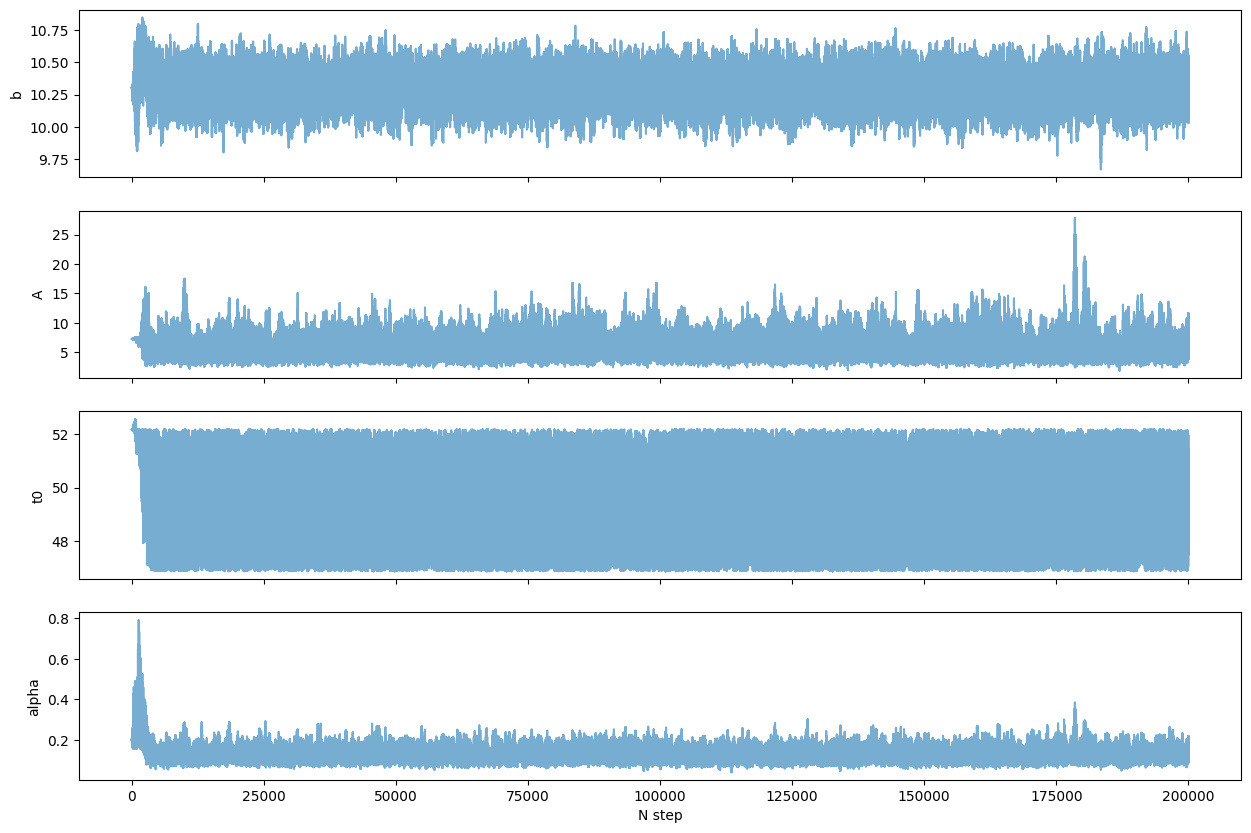

In [10]:
fig, axes = plt.subplots(4, figsize=(15,10), sharex=True)
samples= sampler.get_chain()
labels = ['b', 'A', 't0', 'alpha']

for i, ax in enumerate(axes):
    ax.plot(samples[:,:,i].flatten(), alpha=0.6)
    ax.set_ylabel(labels[i])
    
axes[-1].set_xlabel('N step')

In [11]:
# Now take one point every autocorrelation lenght
tau = sampler.get_autocorr_time()
print(tau)

[53.14022501 69.22785352 79.8925125  75.45524759]


In [12]:
thin_n = int(max(tau))+1
final_samples = sampler.get_chain(discard=4*thin_n, thin=thin_n, flat=True)

In [13]:
final_samples.shape

(2420, 4)

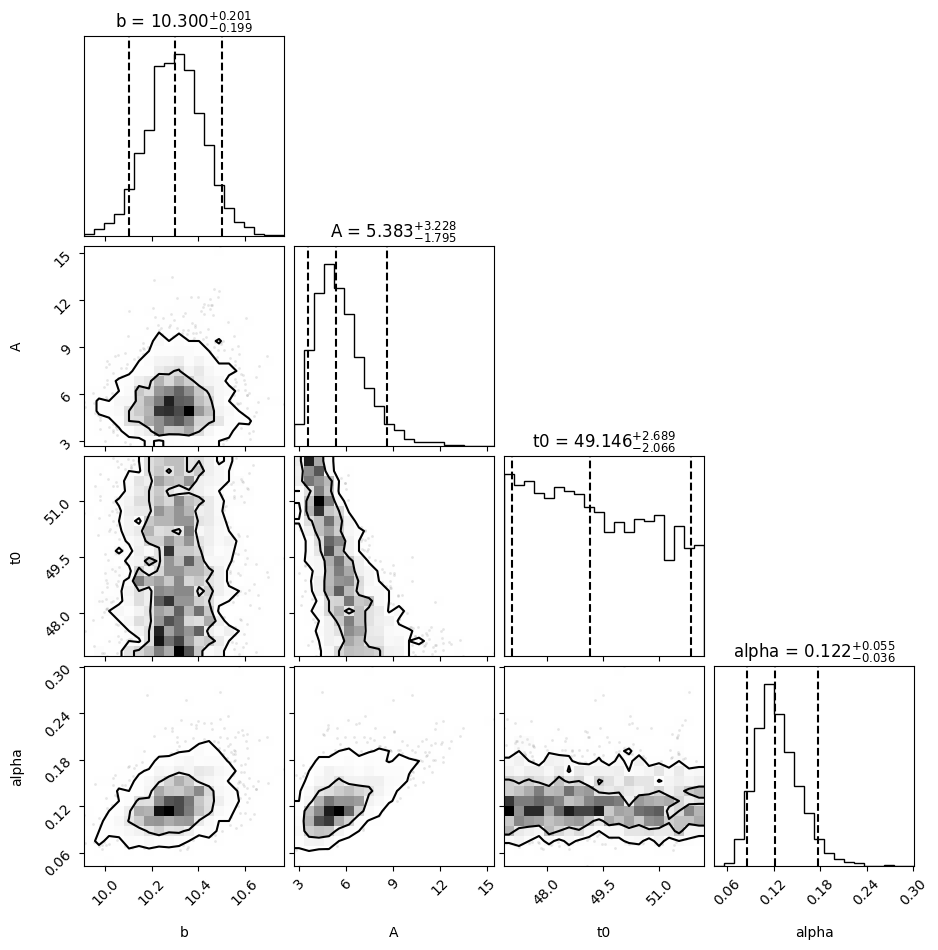

In [14]:
import corner
labels = ["b", "A", "t0", "alpha"]
fig = corner.corner(final_samples, labels=labels, quantiles=[0.05, 0.5, 0.95],
                    show_titles=True, title_fmt='.3f', levels=(0.68, 0.95))
plt.show()

The corner plot shows on diagonal the marginalized distribution for each parameter. The peak represents the most likely value, and the width represents the uncertainty. Off-diagonal, instead, it shows correlations. 

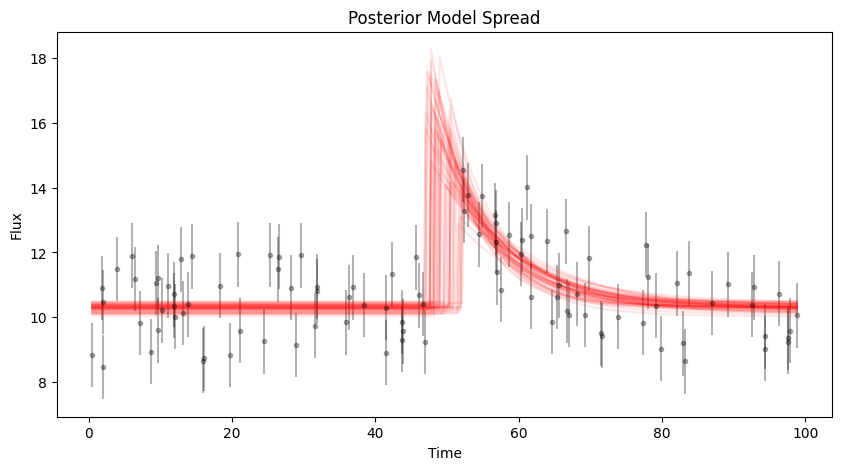

In [15]:
plt.figure(figsize=(10, 5))
plt.errorbar(t, y, yerr=y_err, fmt='.k', alpha=0.3)

# Plot of 50 randomly chosen models
inds = np.random.randint(len(final_samples), size=50)
t_plot = np.linspace(t.min(), t.max(), 500)
for ind in inds:
    sample = final_samples[ind]
    plt.plot(t_plot, burst_model(sample, t_plot), "r", alpha=0.1)

plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Posterior Model Spread")
plt.show()

## PYMC

#### Defining the Model
In PyMC, we define the priors and the likelihood within a with pm.Model() context manager. This creates a computational graph of the statistical model.

In [16]:
import pymc as pm
import arviz as az # Standard for PyMC plotting

# Assuming t, y, y_err are already loaded from the .npy file
with pm.Model() as burst_model:
    # Priors
    # Uniform priors for A, B, and t0
    b = pm.Uniform("b", lower=0, upper=50)
    A = pm.Uniform("A", lower=0, upper=50)
    t0 = pm.Uniform("t0", lower=0, upper=100)
    
    # Prior for alpha: log-uniform is equivalent to pm.Lognormal or 
    # using a flat prior on the log of the variable.
    log_alpha = pm.Uniform("log_alpha", lower=-5, upper=5)
    alpha = pm.Deterministic("alpha", pm.math.exp(log_alpha))

    # The Physical Model
    # Use pm.math.switch to handle the 'if t < t0' logic
    # model = b before t0, and b + A*exp(-(t-t0)*alpha) after
    dt = t - t0
    mu = b + pm.math.switch(dt < 0, 0, A * pm.math.exp(-dt *alpha))

    # Likelihood
    # Normal distribution for the observations
    y_obs = pm.Normal("y_obs", mu=mu, sigma=y_err, observed=y)

#### Sampling the Posterior
PyMC uses the No-U-Turn Sampler (NUTS) by default. Unlike emcee, it doesn't need "walkers" to be initialized in a ball; it uses the gradient of the log-probability to find the posterior.

In [17]:
import pytensor
print(pytensor.config.gcc__cxxflags)

 -Wno-c++11-narrowing -fno-exceptions -fno-unwind-tables -fno-asynchronous-unwind-tables


In [18]:
with burst_model:
    # 1. Imposta un punto di partenza manuale per evitare zone "morte"
    # Usiamo il valore medio di t come partenza per t0
    start = {"b": np.median(y), "A": np.max(y) - np.min(y), "t0": np.mean(t), "log_alpha": 0}
    
    # 2. Specifichiamo i campionatori
    step1 = pm.Slice(vars=[t0])  # Slice è perfetto per t0
    step2 = pm.NUTS(vars=[b, A, log_alpha]) # NUTS per il resto
    
    # 3. Campionamento forzato su 1 core per evitare blocchi Windows
    trace = pm.sample(10000, tune=1000,  initvals=start, cores=1, chains=4, step=[step1, step2])

Sequential sampling (4 chains in 1 job)
CompoundStep
>Slice: [t0]
>NUTS: [b, A, log_alpha]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 42 seconds.


#### Results analysis

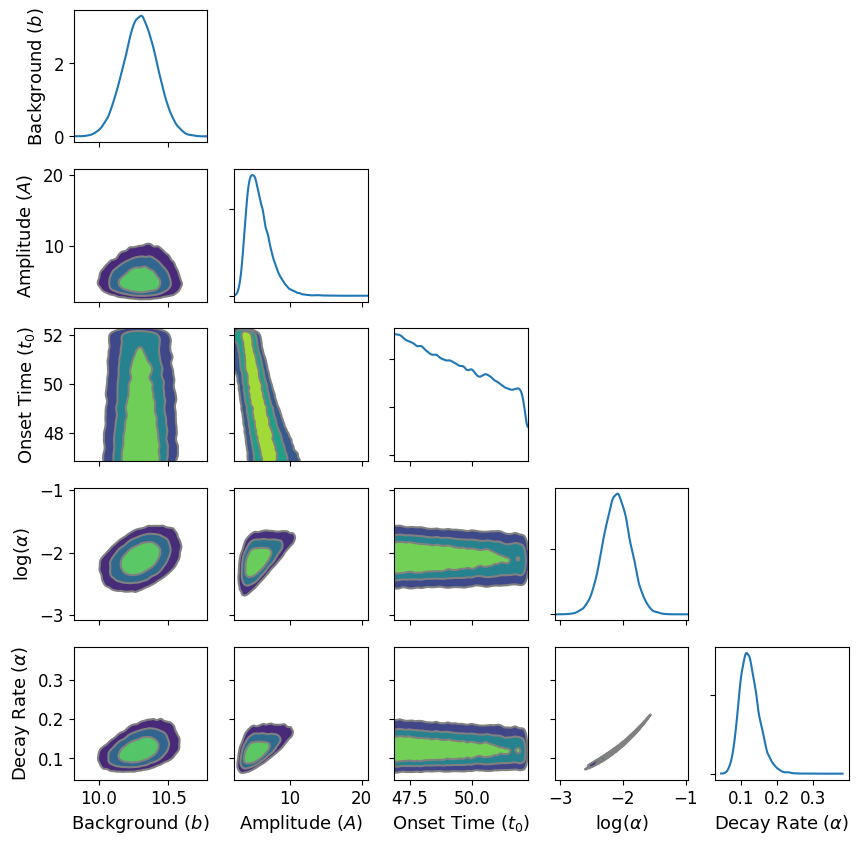

In [19]:
import arviz as az
import matplotlib.pyplot as plt

# 1. Crea una copia per non rovinare i dati originali
trace_labeled = trace.copy()

# 2. Rinomina le variabili nel gruppo posterior
# Usiamo rename_vars o semplicemente assegniamo nuovi nomi alle coordinate
mapping = {
    "b": "Background ($b$)",
    "A": "Amplitude ($A$)",
    "t0": "Onset Time ($t_0$)",
    "log_alpha": r"$\log(\alpha)$",
    "alpha": r"Decay Rate ($\alpha$)"
}

# Applichiamo il rinominamento
trace_labeled.posterior = trace_labeled.posterior.rename_vars(mapping)

# 3. Ora lancia il plot senza il parametro labeller
az.plot_pair(
    trace_labeled, 
    kind='kde', 
    divergences=True, 
    marginals=True,
    figsize=(10, 10), 
    textsize=12
)
plt.show()

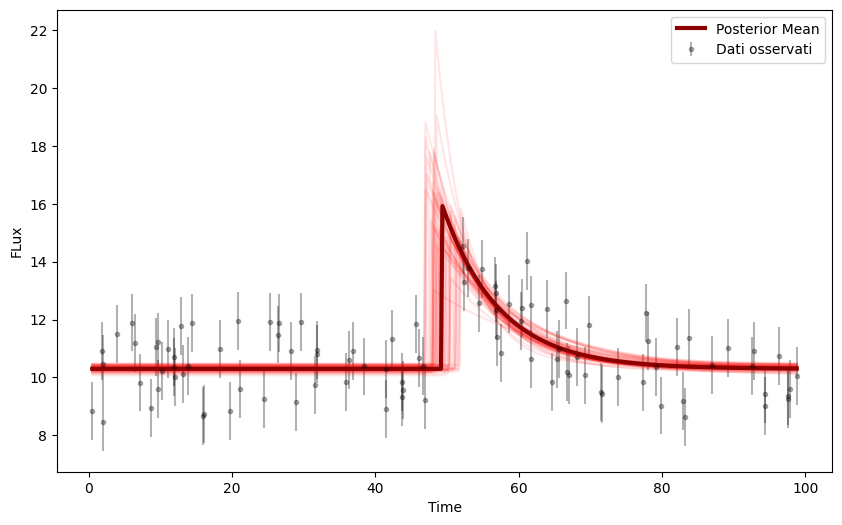

In [20]:
# random extraction of 50 models
samples = az.extract(trace, num_samples=50)

plt.figure(figsize=(10, 6))


plt.errorbar(t, y, yerr=y_err, fmt='.k', alpha=0.3, label='Dati osservati')


t_plot = np.linspace(t.min(), t.max(), 500)

# 50 models to be overplotted
for i in range(50):
 
    A_i = samples['A'].values[i]
    b_i = samples['b'].values[i]
    t0_i = samples['t0'].values[i]
    alpha_i = samples['alpha'].values[i]
    
   
    dt = t_plot - t0_i
    model_i = b_i + np.where(dt < 0, 0, A_i * np.exp(-dt * alpha_i))
    

    plt.plot(t_plot, model_i, color='red', alpha=0.1)

# Mean model
A_mean = trace.posterior['A'].mean().values
b_mean = trace.posterior['b'].mean().values
t0_mean = trace.posterior['t0'].mean().values
alpha_mean = trace.posterior['alpha'].mean().values


dt_mean = t_plot - t0_mean
model_mean = b_mean + np.where(dt_mean < 0, 0, A_mean * np.exp(-dt_mean * alpha_mean))

plt.plot(t_plot, model_mean, color='darkred', lw=3, label='Posterior Mean')
plt.xlabel('Time')
plt.ylabel('FLux')

plt.legend()
plt.show()

In [22]:
post = trace.posterior
variables = ["A", "b", "t0", "alpha"]

print("Results through PyMC:")
print("-" * 35)

# Calcoliamo gli intervalli HDI per tutte le variabili in un colpo solo
hdi_data = az.hdi(trace, hdi_prob=0.95)

for var in variables:
    mean_val = float(post[var].mean())
    std_val = float(post[var].std())
    
    # Estraiamo i due limiti (lower e upper) dall'oggetto HDI
    # hdi_data[var] contiene i due valori [min, max]
    low, high = hdi_data[var].values
    
    print(f"{var:6} = {mean_val:8.3f} ± {std_val:8.3f}  [95% HDI: {low:8.3f}, {high:8.3f}]")

Results through PyMC:
-----------------------------------
A      =    5.716 ±    1.666  [95% HDI:    3.047,    9.019]
b      =   10.296 ±    0.121  [95% HDI:   10.066,   10.543]
t0     =   49.231 ±    1.514  [95% HDI:   46.865,   51.815]
alpha  =    0.126 ±    0.028  [95% HDI:    0.076,    0.183]
